In [1]:
print(5)

5


In [21]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import (
    EfficientNetB0,
    MobileNetV2,
    ResNet50,
    VGG16,
    InceptionV3
)

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

In [22]:
BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Base directory:", BASE_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Base directory: e:\Guvi\Projects\Assignment 5\fish_image_classification
Train exists: True
Validation exists: True
Test exists: True


In [23]:
# Temperary generator for labels

temp_datagen = ImageDataGenerator()

temp_generator = temp_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(temp_generator.class_indices.keys())
NUM_CLASSES = len(class_labels)

print("Number of classes:", NUM_CLASSES)
print("Classes:", class_labels)

Found 6225 images belonging to 11 classes.
Number of classes: 11
Classes: ['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel', 'fish sea_food red_mullet', 'fish sea_food red_sea_bream', 'fish sea_food sea_bass', 'fish sea_food shrimp', 'fish sea_food striped_red_mullet', 'fish sea_food trout']


In [24]:
# Computing class weights

train_class_labels = temp_generator.classes

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_class_labels),
    y=train_class_labels
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class weights:")
for class_index, weight in class_weights.items():
    print(f"{class_labels[class_index]}: {weight:.2f}")

Class weights:
animal fish: 0.52
animal fish bass: 18.86
fish sea_food black_sea_sprat: 0.99
fish sea_food gilt_head_bream: 1.00
fish sea_food hourse_mackerel: 0.99
fish sea_food red_mullet: 0.98
fish sea_food red_sea_bream: 0.99
fish sea_food sea_bass: 1.05
fish sea_food shrimp: 0.98
fish sea_food striped_red_mullet: 1.03
fish sea_food trout: 0.98


In [25]:
# Model configuration

MODEL_CONFIGS = {
    "EfficientNetB0": {
        "model_fn": EfficientNetB0,
        "preprocess_fn": None,
        "fine_tune_layers": 20
    },
    "MobileNetV2": {
        "model_fn": MobileNetV2,
        "preprocess_fn": mobilenet_preprocess,
        "fine_tune_layers": 30
    },
    "ResNet50": {
        "model_fn": ResNet50,
        "preprocess_fn": resnet_preprocess,
        "fine_tune_layers": 30
    },
    "VGG16": {
        "model_fn": VGG16,
        "preprocess_fn": vgg16_preprocess,
        "fine_tune_layers": 4
    },
    "InceptionV3": {
        "model_fn": InceptionV3,
        "preprocess_fn": inception_preprocess,
        "fine_tune_layers": 30
    }
}

In [26]:
# Data Generator functions

def create_generators(preprocess_fn=None):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True,
        width_shift_range=0.1,
        height_shift_range=0.1
    )

    val_test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )

    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True,
        seed=SEED
    )

    val_generator = val_test_datagen.flow_from_directory(
        VAL_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    test_generator = val_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    return train_generator, val_generator, test_generator

In [27]:
# Building model functions

def build_transfer_model(model_fn, model_name):
    base_model = model_fn(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)
    outputs = Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(
        inputs=base_model.input,
        outputs=outputs,
        name=model_name
    )

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model

In [28]:
# Callback function

def get_callbacks():
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )

    return [early_stopping, reduce_lr]

In [29]:
# Function for plot

def plot_history(history, model_name):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [30]:
# Evaluation function

def evaluate_model(model, model_name, test_generator):
    test_generator.reset()

    test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)

    pred_probs = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(pred_probs, axis=1)
    y_true = test_generator.classes

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_labels,
        digits=4,
        output_dict=True,
        zero_division=0
    )

    print(f"{model_name} Test Loss: {test_loss:.4f}")
    print(f"{model_name} Test Accuracy: {test_accuracy:.4f}")
    print()
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_labels,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_labels
    )
    disp.plot(
        cmap="Blues",
        xticks_rotation=90,
        values_format="d"
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    metrics = {
        "model": model_name,
        "test_accuracy": test_accuracy,
        "macro_precision": report_dict["macro avg"]["precision"],
        "macro_recall": report_dict["macro avg"]["recall"],
        "macro_f1": report_dict["macro avg"]["f1-score"],
        "weighted_f1": report_dict["weighted avg"]["f1-score"]
    }

    return metrics

In [31]:
# Training function for one model

def train_one_model(model_name, initial_epochs=10, fine_tune_epochs=10):
    config = MODEL_CONFIGS[model_name]

    print(f"\n{'=' * 60}")
    print(f"Training {model_name}")
    print(f"{'=' * 60}\n")

    train_generator, val_generator, test_generator = create_generators(
        config["preprocess_fn"]
    )

    model, base_model = build_transfer_model(
        config["model_fn"],
        model_name
    )

    print("Stage 1: Training classifier head with frozen base")
    initial_history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=initial_epochs,
        class_weight=class_weights,
        callbacks=get_callbacks()
    )

    plot_history(initial_history, f"{model_name} - Frozen Base")

    print("Stage 2: Fine-tuning top layers")
    base_model.trainable = True

    for layer in base_model.layers[:-config["fine_tune_layers"]]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    fine_tune_history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=fine_tune_epochs,
        class_weight=class_weights,
        callbacks=get_callbacks()
    )

    plot_history(fine_tune_history, f"{model_name} - Fine Tuning")

    metrics = evaluate_model(
        model,
        model_name,
        test_generator
    )

    save_path = MODEL_DIR / f"{model_name.lower()}_finetuned.h5"
    model.save(save_path)

    print(f"{model_name} saved to: {save_path}")

    return model, initial_history, fine_tune_history, metrics


Training EfficientNetB0

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Stage 1: Training classifier head with frozen base
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.8683 - loss: 0.4769 - val_accuracy: 0.9844 - val_loss: 0.0652 - learning_rate: 0.0010
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.9655 - loss: 0.1169 - val_accuracy: 0.9918 - val_loss: 0.0363 - learning_rate: 0.0010
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.9759 - loss: 0.0708 - val_accuracy: 0.9899 - val_loss: 0.0391 - learning_rate: 0.0010
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.9823 - loss: 0.0481 - val_accuracy: 0.9927 - val_loss: 0.0233 - learning_rate: 0.0010
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.9894 - loss: 0.0356 - val_accuracy: 0.9881 - val_loss: 0.0264 - learning_rate: 0.0010
Epoch 6/10
195/195 ━━━━━━━━━━

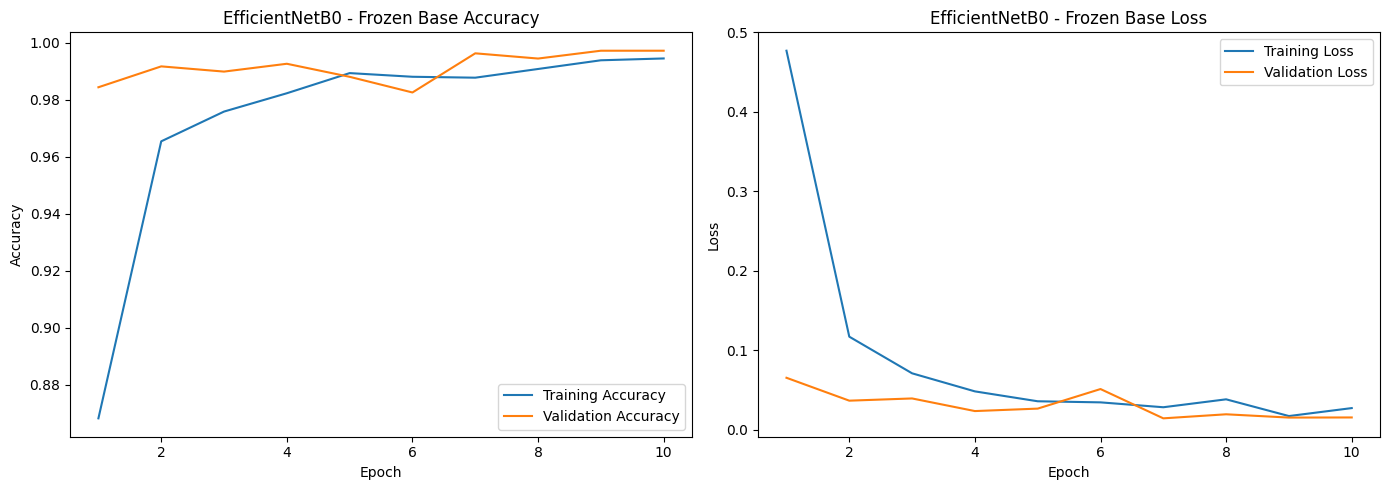

Stage 2: Fine-tuning top layers
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.9316 - loss: 0.2449 - val_accuracy: 0.9945 - val_loss: 0.0223 - learning_rate: 1.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.9698 - loss: 0.1090 - val_accuracy: 0.9927 - val_loss: 0.0250 - learning_rate: 1.0000e-05
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.9806 - loss: 0.0821 - val_accuracy: 0.9936 - val_loss: 0.0244 - learning_rate: 1.0000e-05
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9818 - loss: 0.0720 - val_accuracy: 0.9936 - val_loss: 0.0232 - learning_rate: 2.0000e-06
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.9799 - loss: 0.0688 - val_accuracy: 0.9936 - val_loss: 0.0222 - learning_rate: 2.0000e-06
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9836 - loss: 0.0675 - val_accuracy: 0.9936 - val_loss: 0.0216 - learning_rate: 2.0000e-06
Epoch 7/10
195/195 ━━━━━━━

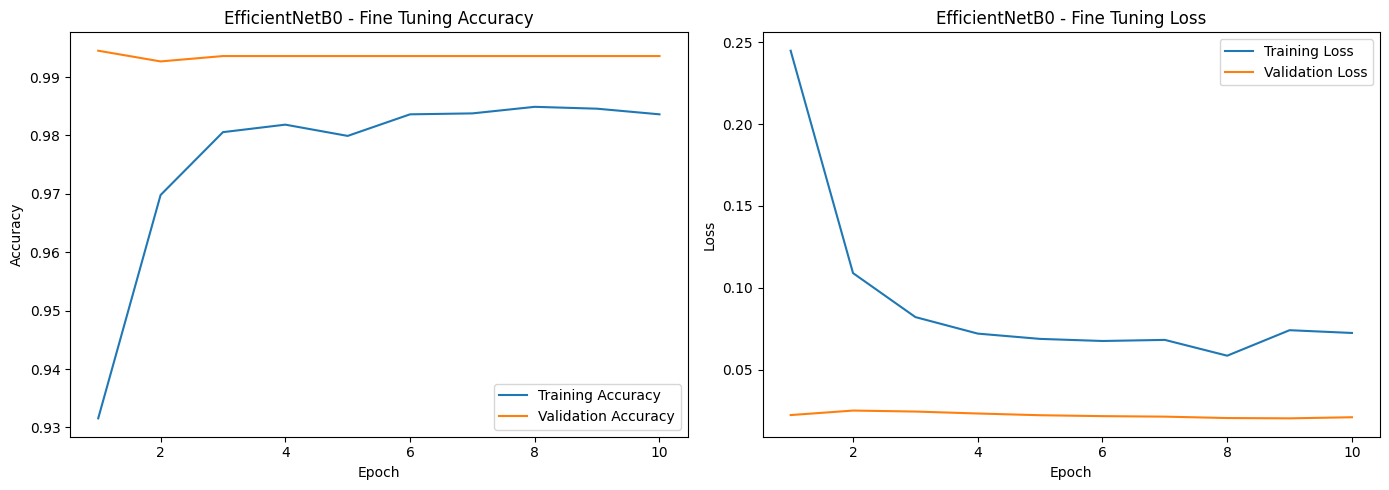

EfficientNetB0 Test Loss: 0.0276
EfficientNetB0 Test Accuracy: 0.9925

                                  precision    recall  f1-score   support

                     animal fish     0.9960    0.9577    0.9765       520
                animal fish bass     0.4231    0.8462    0.5641        13
   fish sea_food black_sea_sprat     1.0000    1.0000    1.0000       298
   fish sea_food gilt_head_bream     0.9903    1.0000    0.9951       305
   fish sea_food hourse_mackerel     1.0000    1.0000    1.0000       286
        fish sea_food red_mullet     0.9966    1.0000    0.9983       291
     fish sea_food red_sea_bream     0.9964    1.0000    0.9982       273
          fish sea_food sea_bass     1.0000    1.0000    1.0000       327
            fish sea_food shrimp     0.9931    1.0000    0.9966       289
fish sea_food striped_red_mullet     1.0000    1.0000    1.0000       293
             fish sea_food trout     1.0000    1.0000    1.0000       292

                        accuracy       

<Figure size 1200x1000 with 0 Axes>

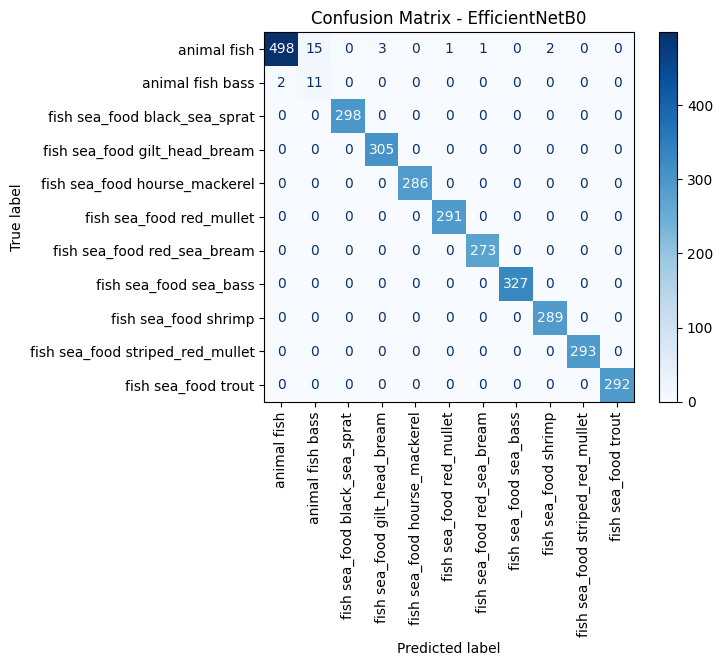

EfficientNetB0 saved to: e:\Guvi\Projects\Assignment 5\fish_image_classification\models\efficientnetb0_finetuned.h5


In [32]:
# Training for EfficientNetB0

results = []

efficientnet_model, efficientnet_initial_history, efficientnet_finetune_history, efficientnet_metrics = train_one_model(
    "EfficientNetB0",
    initial_epochs=10,
    fine_tune_epochs=10
)

results.append(efficientnet_metrics)


Training MobileNetV2

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Stage 1: Training classifier head with frozen base
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - accuracy: 0.8111 - loss: 0.6483 - val_accuracy: 0.9606 - val_loss: 0.1262 - learning_rate: 0.0010
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.9367 - loss: 0.1934 - val_accuracy: 0.9799 - val_loss: 0.0670 - learning_rate: 0.0010
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.9499 - loss: 0.1497 - val_accuracy: 0.9872 - val_loss: 0.0473 - learning_rate: 0.0010
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 282s 1s/step - accuracy: 0.9696 - loss: 0.0822 - val_accuracy: 0.9853 - val_loss: 0.0470 - learning_rate: 0.0010
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.9775 - loss: 0.0645 - val_accuracy: 0.9890 - val_loss: 0.0393 - learning_rate: 0.0010
Epoch 6/10
195/195 ━━━━━━━━━━━━━

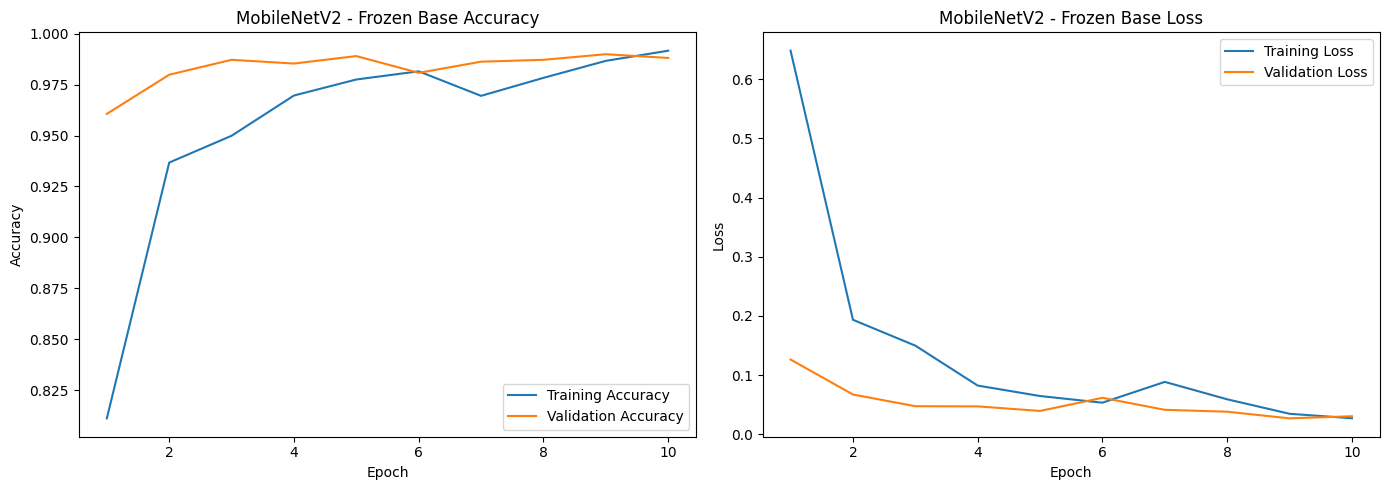

Stage 2: Fine-tuning top layers
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.6893 - loss: 1.9075 - val_accuracy: 0.9890 - val_loss: 0.0223 - learning_rate: 1.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9390 - loss: 0.1634 - val_accuracy: 0.9899 - val_loss: 0.0208 - learning_rate: 1.0000e-05
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.9637 - loss: 0.0943 - val_accuracy: 0.9908 - val_loss: 0.0183 - learning_rate: 1.0000e-05
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 158s 811ms/step - accuracy: 0.9719 - loss: 0.0815 - val_accuracy: 0.9918 - val_loss: 0.0161 - learning_rate: 1.0000e-05
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 157s 803ms/step - accuracy: 0.9761 - loss: 0.0663 - val_accuracy: 0.9927 - val_loss: 0.0151 - learning_rate: 1.0000e-05
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 157s 807ms/step - accuracy: 0.9794 - loss: 0.0576 - val_accuracy: 0.9936 - val_loss: 0.0135 - learning_rate: 1.0000e-05
Epoch 7/10
195/19

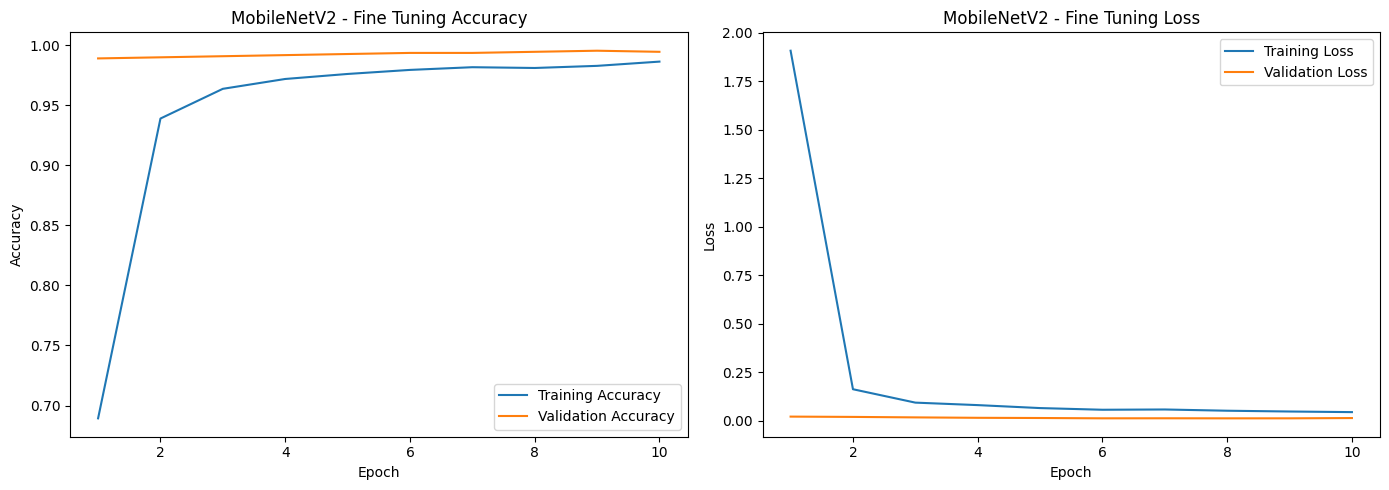

MobileNetV2 Test Loss: 0.0094
MobileNetV2 Test Accuracy: 0.9981

                                  precision    recall  f1-score   support

                     animal fish     0.9962    0.9981    0.9971       520
                animal fish bass     0.9167    0.8462    0.8800        13
   fish sea_food black_sea_sprat     1.0000    1.0000    1.0000       298
   fish sea_food gilt_head_bream     1.0000    0.9967    0.9984       305
   fish sea_food hourse_mackerel     1.0000    0.9965    0.9982       286
        fish sea_food red_mullet     0.9966    1.0000    0.9983       291
     fish sea_food red_sea_bream     0.9964    1.0000    0.9982       273
          fish sea_food sea_bass     1.0000    1.0000    1.0000       327
            fish sea_food shrimp     1.0000    1.0000    1.0000       289
fish sea_food striped_red_mullet     0.9966    0.9966    0.9966       293
             fish sea_food trout     1.0000    1.0000    1.0000       292

                        accuracy             

<Figure size 1200x1000 with 0 Axes>

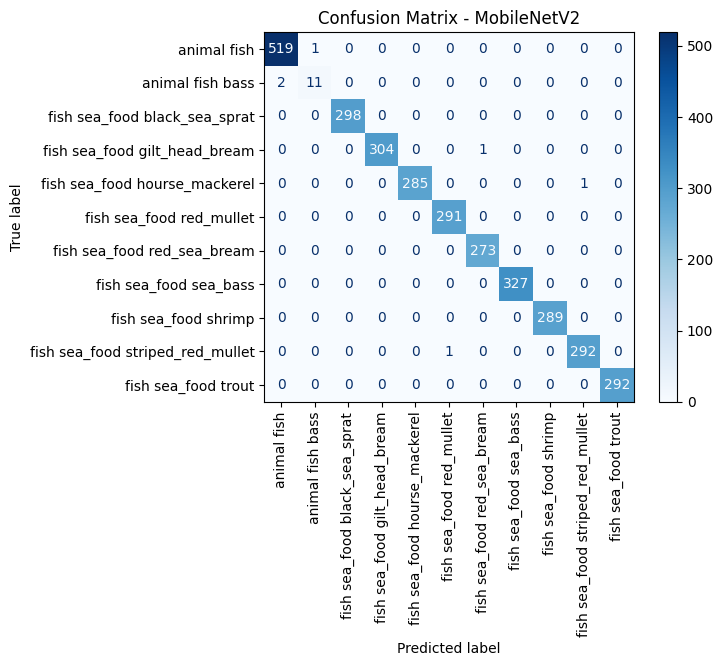

MobileNetV2 saved to: e:\Guvi\Projects\Assignment 5\fish_image_classification\models\mobilenetv2_finetuned.h5


In [33]:
# Train MobileNetV2

mobilenet_model, mobilenet_initial_history, mobilenet_finetune_history, mobilenet_metrics = train_one_model(
    "MobileNetV2",
    initial_epochs=10,
    fine_tune_epochs=10
)

results.append(mobilenet_metrics)


Training ResNet50

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Stage 1: Training classifier head with frozen base
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 559s 3s/step - accuracy: 0.8307 - loss: 0.6227 - val_accuracy: 0.9597 - val_loss: 0.1268 - learning_rate: 0.0010
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - accuracy: 0.9569 - loss: 0.1279 - val_accuracy: 0.9863 - val_loss: 0.0505 - learning_rate: 0.0010
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 493s 3s/step - accuracy: 0.9552 - loss: 0.1641 - val_accuracy: 0.9899 - val_loss: 0.0378 - learning_rate: 0.0010
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 503s 3s/step - accuracy: 0.9666 - loss: 0.1007 - val_accuracy: 0.9918 - val_loss: 0.0215 - learning_rate: 0.0010
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 603s 3s/step - accuracy: 0.9677 - loss: 0.0928 - val_accuracy: 0.9936 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━

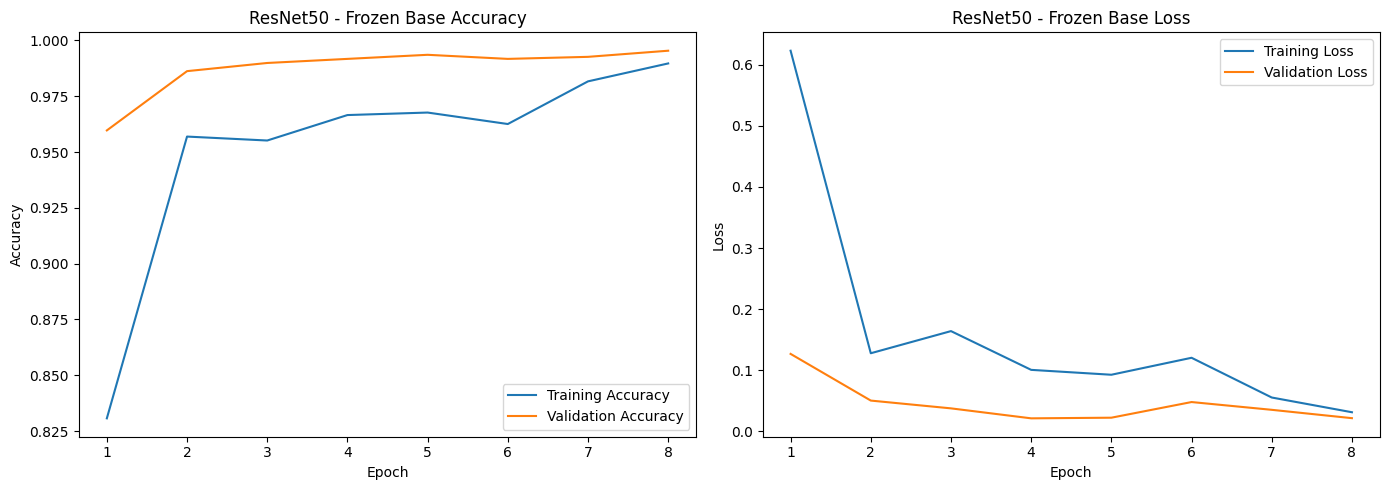

Stage 2: Fine-tuning top layers
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 658s 3s/step - accuracy: 0.8461 - loss: 0.8435 - val_accuracy: 0.9918 - val_loss: 0.0323 - learning_rate: 1.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 712s 3s/step - accuracy: 0.9730 - loss: 0.0928 - val_accuracy: 0.9936 - val_loss: 0.0271 - learning_rate: 1.0000e-05
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 593s 3s/step - accuracy: 0.9798 - loss: 0.0602 - val_accuracy: 0.9945 - val_loss: 0.0259 - learning_rate: 1.0000e-05
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 726s 4s/step - accuracy: 0.9881 - loss: 0.0455 - val_accuracy: 0.9936 - val_loss: 0.0207 - learning_rate: 1.0000e-05
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 714s 4s/step - accuracy: 0.9886 - loss: 0.0399 - val_accuracy: 0.9936 - val_loss: 0.0161 - learning_rate: 1.0000e-05
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 629s 3s/step - accuracy: 0.9913 - loss: 0.0365 - val_accuracy: 0.9954 - val_loss: 0.0161 - learning_rate: 1.0000e-05
Epoch 7/10
195/195 ━━━━━━━

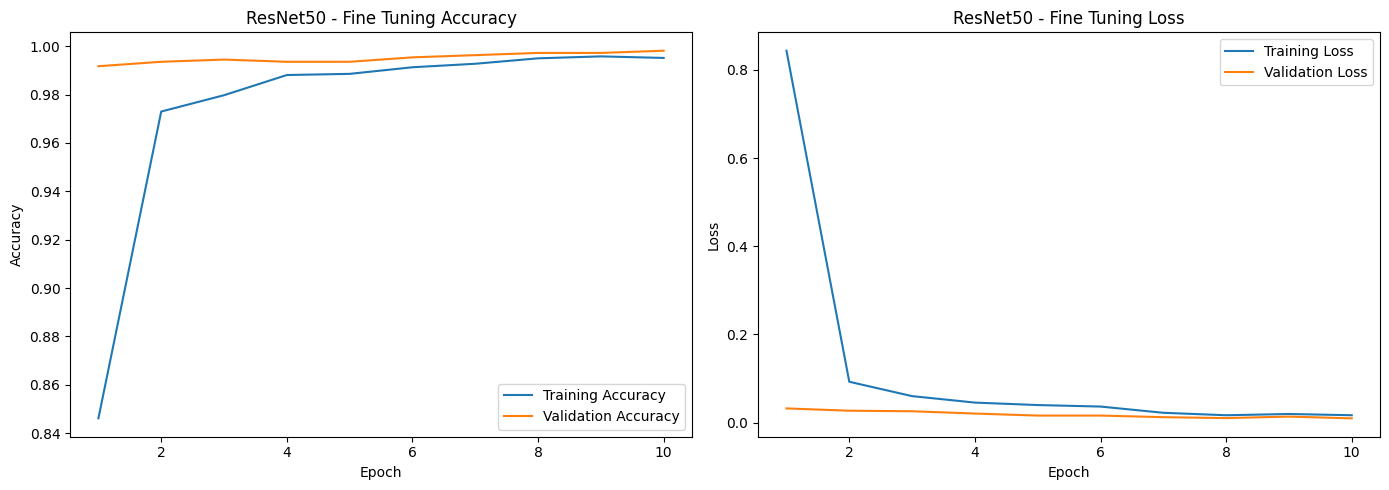

ResNet50 Test Loss: 0.0067
ResNet50 Test Accuracy: 0.9975

                                  precision    recall  f1-score   support

                     animal fish     0.9961    0.9904    0.9932       520
                animal fish bass     0.6875    0.8462    0.7586        13
   fish sea_food black_sea_sprat     1.0000    1.0000    1.0000       298
   fish sea_food gilt_head_bream     1.0000    0.9967    0.9984       305
   fish sea_food hourse_mackerel     1.0000    1.0000    1.0000       286
        fish sea_food red_mullet     1.0000    1.0000    1.0000       291
     fish sea_food red_sea_bream     0.9964    1.0000    0.9982       273
          fish sea_food sea_bass     1.0000    1.0000    1.0000       327
            fish sea_food shrimp     1.0000    1.0000    1.0000       289
fish sea_food striped_red_mullet     1.0000    1.0000    1.0000       293
             fish sea_food trout     1.0000    1.0000    1.0000       292

                        accuracy                   

<Figure size 1200x1000 with 0 Axes>

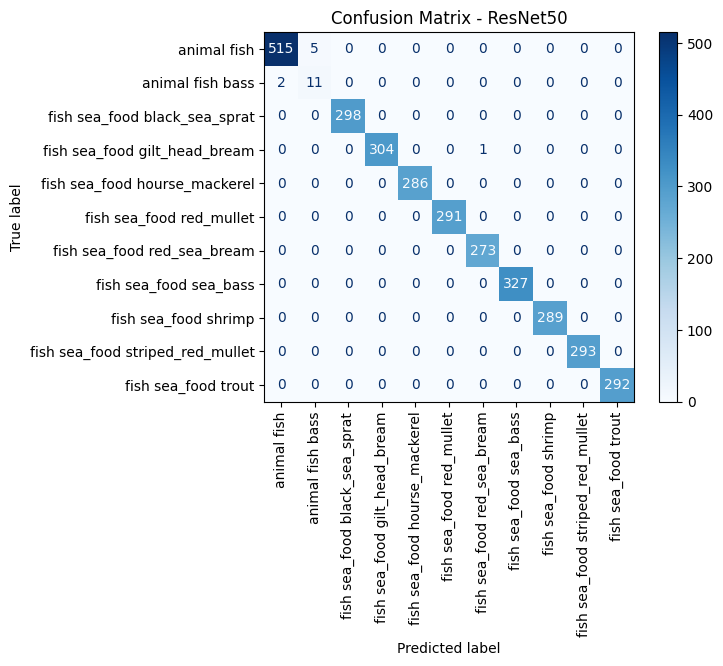

ResNet50 saved to: e:\Guvi\Projects\Assignment 5\fish_image_classification\models\resnet50_finetuned.h5


In [34]:
# Training RestNet50

resnet_model, resnet_initial_history, resnet_finetune_history, resnet_metrics = train_one_model(
    "ResNet50",
    initial_epochs=10,
    fine_tune_epochs=10
)

results.append(resnet_metrics)


Training VGG16

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Stage 1: Training classifier head with frozen base
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 588s 3s/step - accuracy: 0.7031 - loss: 1.3186 - val_accuracy: 0.8929 - val_loss: 0.4259 - learning_rate: 0.0010
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 566s 3s/step - accuracy: 0.8832 - loss: 0.3716 - val_accuracy: 0.9835 - val_loss: 0.0521 - learning_rate: 0.0010
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 569s 3s/step - accuracy: 0.9293 - loss: 0.2170 - val_accuracy: 0.9844 - val_loss: 0.0393 - learning_rate: 0.0010
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 671s 3s/step - accuracy: 0.9248 - loss: 0.3135 - val_accuracy: 0.9222 - val_loss: 0.5288 - learning_rate: 0.0010
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 584s 3s/step - accuracy: 0.9439 - loss: 0.2170 - val_accuracy: 0.9835 - val_loss: 0.0599 - learning_rate: 0.0010
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━

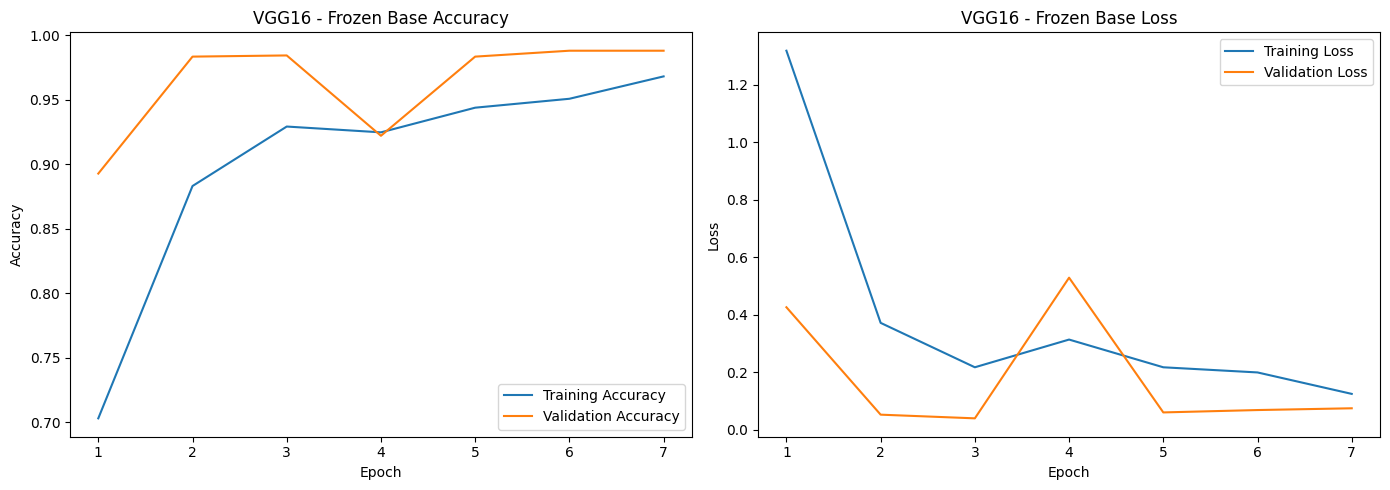

Stage 2: Fine-tuning top layers
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 687s 4s/step - accuracy: 0.9590 - loss: 0.1390 - val_accuracy: 0.9908 - val_loss: 0.0256 - learning_rate: 1.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 683s 4s/step - accuracy: 0.9724 - loss: 0.0786 - val_accuracy: 0.9936 - val_loss: 0.0215 - learning_rate: 1.0000e-05
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1217s 6s/step - accuracy: 0.9767 - loss: 0.0675 - val_accuracy: 0.9945 - val_loss: 0.0201 - learning_rate: 1.0000e-05
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 678s 3s/step - accuracy: 0.9785 - loss: 0.0730 - val_accuracy: 0.9936 - val_loss: 0.0225 - learning_rate: 1.0000e-05
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 670s 3s/step - accuracy: 0.9891 - loss: 0.0283 - val_accuracy: 0.9945 - val_loss: 0.0111 - learning_rate: 1.0000e-05
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2053s 11s/step - accuracy: 0.9905 - loss: 0.0307 - val_accuracy: 0.9945 - val_loss: 0.0108 - learning_rate: 1.0000e-05
Epoch 7/10
195/195 ━━━━

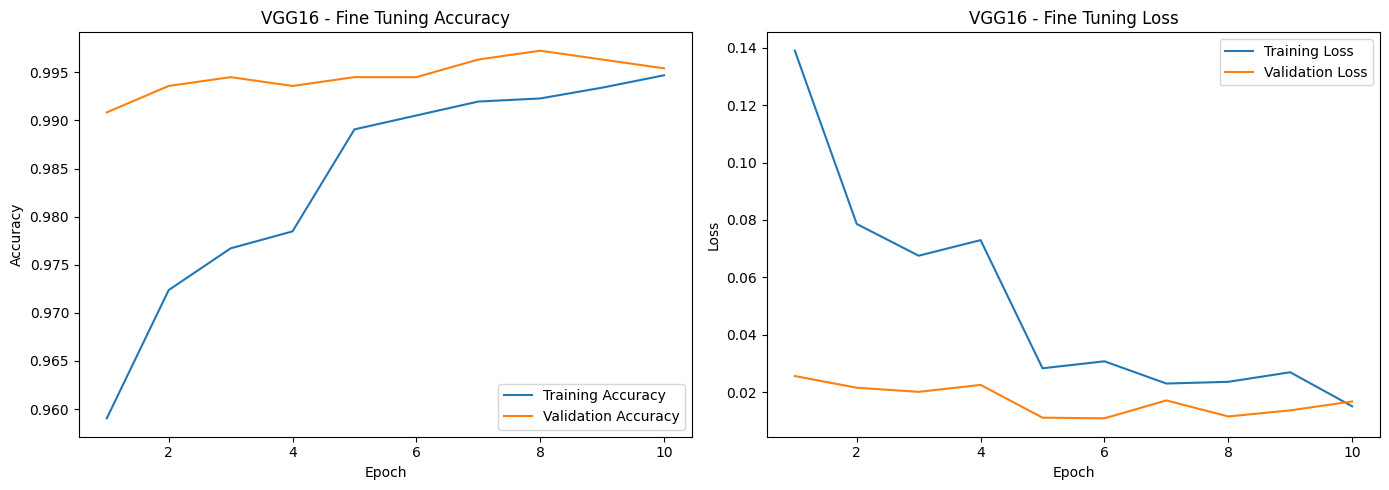

VGG16 Test Loss: 0.0130
VGG16 Test Accuracy: 0.9969

                                  precision    recall  f1-score   support

                     animal fish     0.9961    0.9942    0.9952       520
                animal fish bass     0.9167    0.8462    0.8800        13
   fish sea_food black_sea_sprat     1.0000    1.0000    1.0000       298
   fish sea_food gilt_head_bream     0.9967    0.9967    0.9967       305
   fish sea_food hourse_mackerel     0.9931    1.0000    0.9965       286
        fish sea_food red_mullet     1.0000    0.9897    0.9948       291
     fish sea_food red_sea_bream     0.9964    1.0000    0.9982       273
          fish sea_food sea_bass     1.0000    1.0000    1.0000       327
            fish sea_food shrimp     1.0000    1.0000    1.0000       289
fish sea_food striped_red_mullet     0.9899    1.0000    0.9949       293
             fish sea_food trout     1.0000    0.9966    0.9983       292

                        accuracy                         

<Figure size 1200x1000 with 0 Axes>

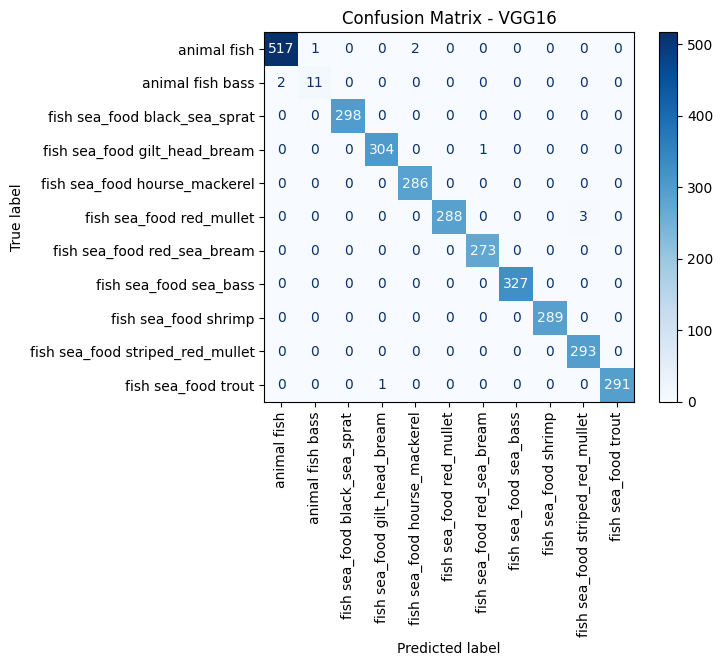

VGG16 saved to: e:\Guvi\Projects\Assignment 5\fish_image_classification\models\vgg16_finetuned.h5


In [35]:
# Trainging VGG16

vgg16_model, vgg16_initial_history, vgg16_finetune_history, vgg16_metrics = train_one_model(
    "VGG16",
    initial_epochs=10,
    fine_tune_epochs=10
)

results.append(vgg16_metrics)


Training InceptionV3

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.
Stage 1: Training classifier head with frozen base
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 196s 966ms/step - accuracy: 0.7046 - loss: 0.9468 - val_accuracy: 0.9359 - val_loss: 0.2255 - learning_rate: 0.0010
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 182s 934ms/step - accuracy: 0.8554 - loss: 0.4144 - val_accuracy: 0.9386 - val_loss: 0.1875 - learning_rate: 0.0010
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 182s 931ms/step - accuracy: 0.8893 - loss: 0.2990 - val_accuracy: 0.9606 - val_loss: 0.1420 - learning_rate: 0.0010
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 183s 939ms/step - accuracy: 0.8888 - loss: 0.2986 - val_accuracy: 0.9414 - val_loss: 0.1682 - learning_rate: 0.0010
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 183s 939ms/step - accuracy: 0.9229 - loss: 0.2051 - val_accuracy: 0.9579 - val_loss: 0.1177 - learning_rate: 0.0010
Epoch 6/10
195/19

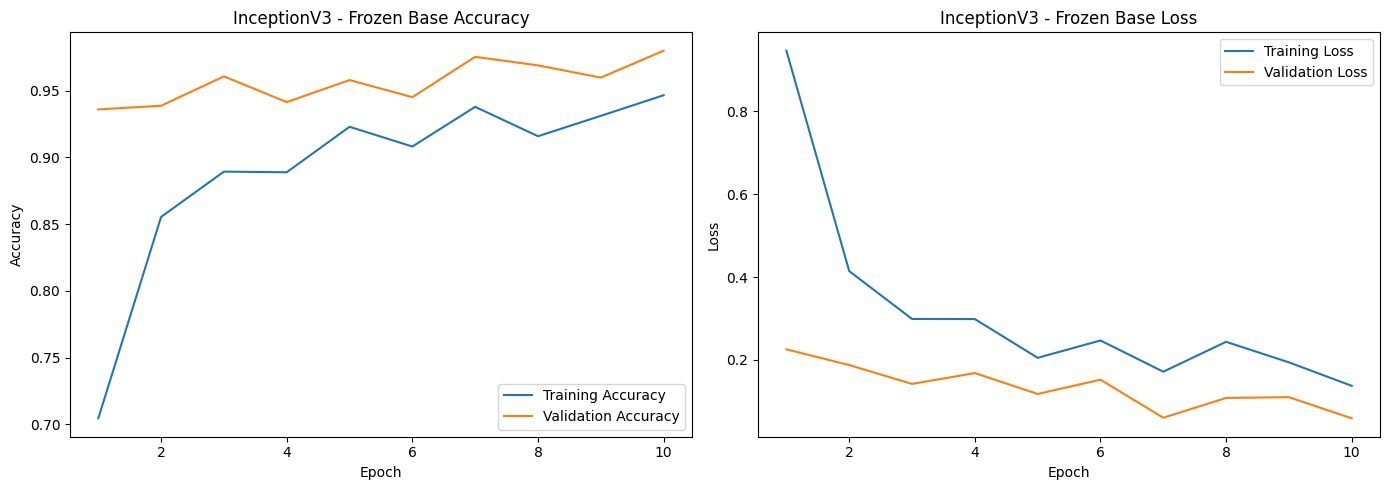

Stage 2: Fine-tuning top layers
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.7754 - loss: 0.7519 - val_accuracy: 0.9799 - val_loss: 0.0732 - learning_rate: 1.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 188s 963ms/step - accuracy: 0.9219 - loss: 0.2590 - val_accuracy: 0.9835 - val_loss: 0.0701 - learning_rate: 1.0000e-05
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 190s 972ms/step - accuracy: 0.9380 - loss: 0.1778 - val_accuracy: 0.9863 - val_loss: 0.0574 - learning_rate: 1.0000e-05
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 188s 961ms/step - accuracy: 0.9516 - loss: 0.1510 - val_accuracy: 0.9872 - val_loss: 0.0518 - learning_rate: 1.0000e-05
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 187s 959ms/step - accuracy: 0.9605 - loss: 0.1101 - val_accuracy: 0.9872 - val_loss: 0.0440 - learning_rate: 1.0000e-05
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 186s 952ms/step - accuracy: 0.9629 - loss: 0.1178 - val_accuracy: 0.9890 - val_loss: 0.0419 - learning_rate: 1.0000e-05
Epoch 7/10


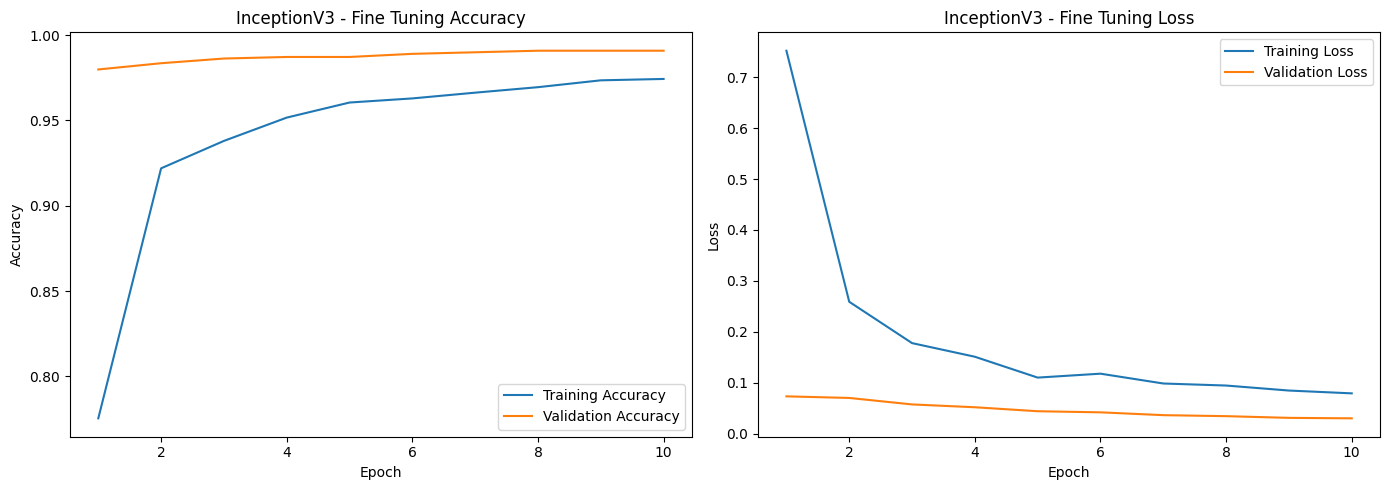

InceptionV3 Test Loss: 0.0222
InceptionV3 Test Accuracy: 0.9944

                                  precision    recall  f1-score   support

                     animal fish     0.9961    0.9769    0.9864       520
                animal fish bass     0.4783    0.8462    0.6111        13
   fish sea_food black_sea_sprat     1.0000    1.0000    1.0000       298
   fish sea_food gilt_head_bream     1.0000    0.9967    0.9984       305
   fish sea_food hourse_mackerel     1.0000    1.0000    1.0000       286
        fish sea_food red_mullet     0.9966    0.9931    0.9948       291
     fish sea_food red_sea_bream     0.9964    1.0000    0.9982       273
          fish sea_food sea_bass     1.0000    1.0000    1.0000       327
            fish sea_food shrimp     1.0000    1.0000    1.0000       289
fish sea_food striped_red_mullet     0.9932    0.9966    0.9949       293
             fish sea_food trout     1.0000    1.0000    1.0000       292

                        accuracy             

<Figure size 1200x1000 with 0 Axes>

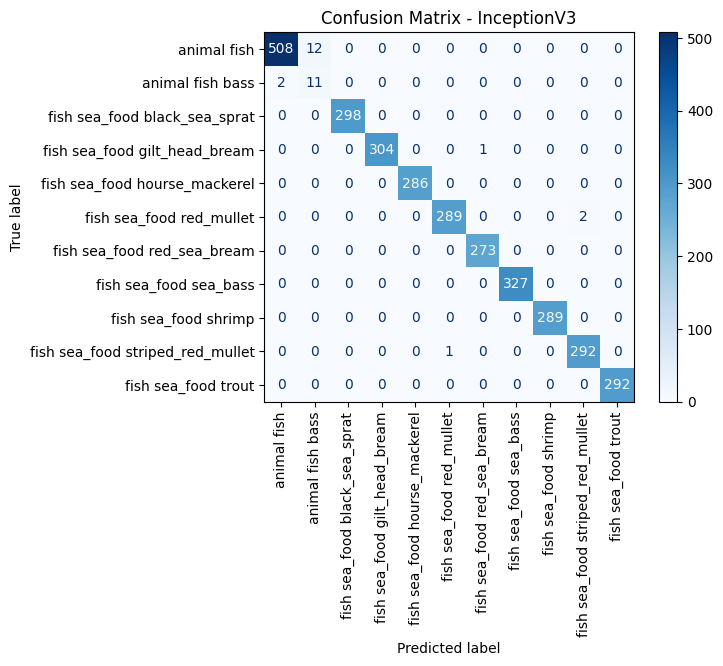

InceptionV3 saved to: e:\Guvi\Projects\Assignment 5\fish_image_classification\models\inceptionv3_finetuned.h5


In [36]:
# Train InceptionV3

inception_model, inception_initial_history, inception_finetune_history, inception_metrics = train_one_model(
    "InceptionV3",
    initial_epochs=10,
    fine_tune_epochs=10
)

results.append(inception_metrics)

In [37]:
# Comparing models

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

results_df

,model,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,MobileNetV2,0.998117,0.991122,0.984913,0.987888,0.998099
1,VGG16,0.996862,0.989891,0.983943,0.986782,0.996844
2,ResNet50,0.997490,0.970907,0.984842,0.977127,0.997600
3,InceptionV3,0.994352,0.950949,0.982683,0.962161,0.994941
4,EfficientNetB0,0.992469,0.945035,0.982168,0.957153,0.993289


In [38]:
# Saving the comparison table

results_df.to_csv(BASE_DIR / "model_comparison_results.csv", index=False)

print("Comparison results saved.")

Comparison results saved.
